# Test Sensitivity of Models to Negative-Dataset Composition

Overall Goal
- Quantify how the choice of negative training examples affects D-MPNN performance for hit prediction on the PK + 37K screen.
- Sweep negative-set size, negative-selection strategy (random / similar to positives / diverse), and random seed under both class-imbalanced (all positives) and class-balanced (positives subsampled to preserve the original positive:negative ratio) modes.
- Evaluate each trained model on a held-out 20% random test set and a restricted-similarity external validation set.

Relation to Manuscript
- Related to Figure S2.

Takeaways
- Model performance is sensitive to both the number and selection method of negatives, with diminishing returns past a certain negative-set size.
- Random and diverse negative selection tend to generalize better to the restricted-similarity validation set than negatives chosen for similarity to positives.
- Class-balanced and class-imbalanced modes give qualitatively similar trends, supporting use of the full positive set in the main models.

Helper Functions
- `aucs`: compute auROC and auPR from ground-truth labels and predicted scores.
- `_load_precomputed`: load and normalize precomputed per-mode results CSVs into a unified schema for plotting.

Scientific Methodology
- Built negative subsets at 7 sizes (pos/2 up to all available negatives) using three selection strategies: random, most-similar-to-positives (Tanimoto on RDKit fingerprints), and diverse (MaxMin via `SimDivFilters`).
- For class-balanced mode, subsampled positives to match the original negative:positive ratio at each negative-set size.
- Generated 3 seeds per (size, strategy) combination and emitted shell scripts to train Chemprop D-MPNN models with rdkit_2d_normalized features and a fixed hyperparameter set.
- Predicted on the 20% random test set and the external (restricted-similarity) validation set, computed auROC and auPR per run, and aggregated results into per-mode CSVs.
- Plotted FacetGrid line plots of auROC/auPR vs. negative-set size, faceted by test set and colored by selection strategy, saved per-mode to the figure-panels direct

In [16]:
import subprocess

import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import seaborn as sns
import tqdm
from rdkit import Chem, SimDivFilters
from rdkit.Chem import DataStructs
from sklearn.metrics import auc, precision_recall_curve, roc_auc_score

## First collect the data we'll be working with and validation sets

In [18]:
# lets use the 37K+PK data as our training data
df = pd.read_csv("../data/data_prep_for_ml/data_prep_for_ml_pk_37k_screen/TRAIN_03_19_2022.csv")

# we'll hold out a random set from here for testing
# 20% test set will be sufficient since it is random and class balanced
# so for testing, use '../data/TEST_03_19_2022.csv'

# we'll also test on all the validation molecules we have predicted on
# since their scaffolds are quite different- easy,med,hard,molport
# so for testing, use '../data/cleaned_easy_med_hard_val_sets_800k_10_03_2022.csv'
df

,Name,SMILES,hit
0,BRD-K93123848,Cn1c(nc2cc(ccc12)Oc1ccnc(c1)-c1ncc([nH]1)C(F)(...,1.0
1,BRD-K30309936,C[C@H]1CCCCO[C@H](CN(C)Cc2ccc(cc2)C(F)(F)F)[C@...,1.0
2,TRIMETHADIONE,CN1C(=O)OC(C)(C)C1=O,1.0
3,BRD-K76424103,C[C@]1([C@@H](N(Cc2ccccc2)C(=O)c2ccccc21)c1ccc...,1.0
4,BRD-K65130196,CC(C)(C)NCCCCOc1ccc(cc1C(C)(C)C)Cl,1.0
...,...,...,...
30962,BRD-K24978625,N[C@@H]1CC[C@@H](CCn2cc(nn2)C2CCCCC2)O[C@H]1CO,0.0
30963,BRD-K16976282,C[C@H]1CCCCO[C@H](CN(C)S(=O)(=O)C)[C@@H](C)CN(...,0.0
30964,BRD-K53638538,O[C@@H]1CCCC[C@H]1O,0.0
30965,BRD-K77119472,CO[C@@H]1CN(C)C(=O)c2cc(ccc2OC[C@H](C)N(C[C@@H...,0.0


In [ ]:
# Set paths for inputs and outputs for both modes.
# Each mode writes its datasets, training script, models, and figures to its own directory
# so the two experiments can coexist without colliding.
modes = {
    "class_imbalanced": {
        "out_dir": "../out/experiment_to_test_different_negative_datasets_seeded",
        "fig_dir": "../figure_panels/negative_dataset_example_seeded",
        "bash_dir": "S2_experiment_to_test_diff_neg_datasets_train_models_seeded.sh",
        "models_dir": "models/experiment_with_diff_neg_datasets_seeded",
        "balanced": False,
    },
    "class_balanced": {
        "out_dir": "../out/experiment_to_test_different_negative_datasets_class_balanced",
        "fig_dir": "../figure_panels/negative_dataset_example_class_balanced",
        "bash_dir": "S2_experiment_to_test_diff_neg_datasets_train_models_class_balanced.sh",
        "models_dir": "models/experiment_with_diff_neg_datasets_class_balanced",
        "balanced": True,
    },
}

## Let's split into sets where we have different proportions of positive:negative data

In [ ]:
pos = sum(df["hit"])
print("num pos: ", pos)

num_neg = [pos / 2, pos, pos * 2, pos * 4, pos * 8, pos * 16, len(df) - pos]
num_neg = [int(x) for x in num_neg]
print("number of neg to test:", num_neg)

# Calculate the ratio of negative to positive in the original dataframe
# (used by class-balanced mode to compute matching positive subset sizes)
total_pos = sum(df["hit"])
total_neg = len(df) - total_pos
neg_to_pos_ratio = total_neg / total_pos

print("Positive samples:", total_pos)
print("Negative samples:", total_neg)
print("Negative to positive ratio:", neg_to_pos_ratio)

# Calculate the corresponding number of positive samples for each dataset size
num_pos = [int(neg / neg_to_pos_ratio) for neg in num_neg]

assert all(
    abs((neg / pos_n) - neg_to_pos_ratio) < 0.5 for neg, pos_n in zip(num_neg, num_pos)
), "Positive-to-negative ratio in subsets does not match the original ratio!"

print("Number of negatives to test:", num_neg)
print("Number of positives to test:", num_pos)

# Preprocess some pos and neg dfs and fp lists for later processing
negative_options = df[df["hit"] == 0.0]
positive_options = df[df["hit"] == 1.0]

all_neg_fps = [Chem.RDKFingerprint(Chem.MolFromSmiles(smi)) for smi in list(negative_options["SMILES"])]
all_pos_fps = [Chem.RDKFingerprint(Chem.MolFromSmiles(smi)) for smi in list(positive_options["SMILES"])]

# Preprocess sorted indices for second method of selection (most similar to positive)
# Used directly by class-imbalanced mode (positive set is fixed across seeds).
# Class-balanced mode recomputes this per (seed, size) since the positive subset varies.
tan_sims_from_all_neg_to_pos = [
    max(DataStructs.BulkTanimotoSimilarity(query_fp, all_pos_fps)) for query_fp in tqdm.tqdm(all_neg_fps)
]
sorted_indices_most_similar = np.argsort(
    [1.0 - x for x in tan_sims_from_all_neg_to_pos]
)  # subtract from 1 so we argsort in most similar to least similar

In [ ]:
def calculate_pairwise_tanimoto(fps_indices, fps_list):
    """
    Compute pairwise Tanimoto similarities for a selected subset of fingerprints.

    Parameters:
    fps_indices (iterable): Indices (from the original dataframe) of the fingerprints to compare.
    fps_list (list): List of RDKit fingerprint objects for all negative molecules.

    Returns:
    np.ndarray: 1D array of pairwise Tanimoto similarities (upper triangle, no diagonal).
    """
    # Convert dataframe indices to positional indices for alignment with fps_list
    positional_indices = [negative_options.index.get_loc(idx) for idx in fps_indices]
    selected_fps = [fps_list[idx] for idx in positional_indices]

    similarity_matrix = np.zeros((len(selected_fps), len(selected_fps)))

    for i in range(len(selected_fps)):
        similarity_matrix[i, i:] = DataStructs.BulkTanimotoSimilarity(selected_fps[i], selected_fps[i:])

    # Extract upper triangle of the matrix (excluding the diagonal)
    pairwise_similarities = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]
    return pairwise_similarities


# loop with random seed so we have multiple datasets for each size
# note that for class-imbalanced method 2, you'll always get the same dataset - thats fine
num_datasets_per_size = 3  # Specify how many datasets you want per size

for mode_name, mode in modes.items():
    out_dir = mode["out_dir"]
    is_balanced = mode["balanced"]
    print(f"\n=== Generating datasets for mode: {mode_name} ===")

    for seed in range(num_datasets_per_size):

        # Set random seed for reproducibility
        np.random.seed(seed)

        for idx, i in enumerate(num_neg):
            if is_balanced:
                neg_count = num_neg[idx]
                pos_count = num_pos[idx]
                print(f"Testing with {pos_count} positives and {neg_count} negatives")
                clean_random = f"random_seed_{seed}_pos_{pos_count}_neg_{neg_count}"
                clean_similar = f"similar_seed_{seed}_pos_{pos_count}_neg_{neg_count}"
                clean_diverse = f"diverse_seed_{seed}_pos_{pos_count}_neg_{neg_count}"
            else:
                neg_count = i
                print("testing negative of #: " + str(i))
                clean_random = f"random_seed_{seed}_N_{i}"
                clean_similar = f"similar_seed_{seed}_N_{i}"
                clean_diverse = f"diverse_seed_{seed}_N_{i}"

            # Build negative sets in different ways
            # First way: random!
            rand_neg = negative_options.sample(n=neg_count, replace=False, random_state=seed)
            if is_balanced:
                # First method: random negatives
                rand = pd.concat(
                    [
                        rand_neg,
                        positive_options.sample(n=pos_count, replace=False, random_state=seed),
                    ]
                ).sample(frac=1)
            else:
                rand = pd.concat([rand_neg, positive_options]).sample(
                    frac=1, replace=False, random_state=seed
                )  # add to pos and shuffle
            rand.to_csv(f"{out_dir}/{clean_random}.csv", index=False)

            # Second way: most similar to positive
            if is_balanced:
                # Second method: most similar negatives
                # Recompute similarity against the positive subset for this seed
                pos_subset = positive_options.sample(n=pos_count, replace=False, random_state=seed)

                # Select the indices of the positive subset in the original positive dataframe
                pos_subset_indices = positive_options.index.get_indexer(pos_subset.index)
                pos_subset_fps = [all_pos_fps[k] for k in pos_subset_indices]

                # Compute Tanimoto similarities using the positive subset fingerprints
                # Process sorted indices for second method of selection (most similar to positive)
                tan_sims_subset = [
                    max(DataStructs.BulkTanimotoSimilarity(query_fp, pos_subset_fps)) for query_fp in tqdm.tqdm(all_neg_fps)
                ]
                local_sorted_similar = np.argsort(
                    [1.0 - x for x in tan_sims_subset]
                )  # Most similar to least similar

                set_of_sorted_similar_indices = local_sorted_similar[:neg_count]
            else:
                # Here, seeds only change the order of compounds in the df
                set_of_sorted_similar_indices = sorted_indices_most_similar[0:i]

            similar_neg = negative_options.iloc[set_of_sorted_similar_indices, :]
            if is_balanced:
                similar = pd.concat(
                    [similar_neg, positive_options.sample(n=pos_count, replace=False)]
                ).sample(frac=1)
            else:
                similar = pd.concat([similar_neg, positive_options]).sample(
                    frac=1, replace=False, random_state=seed
                )  # add to pos and shuffle
            similar.to_csv(f"{out_dir}/{clean_similar}.csv", index=False)

            # Third way: most diverse - use  MaxMin algorithm
            # (Ashton, M. et. al., Quant. Struct.-Act. Relat., 21 (2002), 598-604).
            # http://rdkit.blogspot.com/2014/08/picking-diverse-compounds-from-large.html
            # takes a ton of time for larger Ns
            mmp = SimDivFilters.MaxMinPicker()
            diverse_indices = mmp.LazyBitVectorPick(all_neg_fps, len(all_neg_fps), neg_count, seed=seed)
            diverse_neg = negative_options.iloc[diverse_indices, :]
            if is_balanced:
                diverse = pd.concat(
                    [
                        diverse_neg,
                        positive_options.sample(n=pos_count, replace=False, random_state=seed),
                    ]
                ).sample(frac=1)
            else:
                diverse = pd.concat([diverse_neg, positive_options]).sample(
                    frac=1, replace=False, random_state=seed
                )  # add to pos and shuffle
            diverse.to_csv(f"{out_dir}/{clean_diverse}.csv", index=False)

            # Now, let's prove to ourselves that we did this right by plotting one of the small examples
            # Batch similarity calculation for faster computation
            if neg_count < 1000:  # plot to confirm selection is working as intended
                # For random negatives
                random_tanimoto_scores = calculate_pairwise_tanimoto(rand_neg.index, all_neg_fps)
                plt.hist(random_tanimoto_scores, bins=30, label="random", alpha=0.7)

                # For similar negatives
                similar_tanimoto_scores = calculate_pairwise_tanimoto(
                    negative_options.iloc[set_of_sorted_similar_indices].index, all_neg_fps
                )
                plt.hist(similar_tanimoto_scores, bins=30, label="similar", alpha=0.7)

                # For diverse negatives
                diverse_tanimoto_scores = calculate_pairwise_tanimoto(
                    negative_options.iloc[diverse_indices].index, all_neg_fps
                )
                plt.hist(diverse_tanimoto_scores, bins=30, label="diverse", alpha=0.7)

                # Show plot
                plt.legend()
                plt.title(f"Pairwise Tanimoto Similarities ({mode_name})")
                plt.xlabel("Tanimoto Similarity")
                plt.ylabel("Frequency")
                plt.tight_layout()
                plt.show()

## Prep script to train models on these different datasets

In [26]:
for mode_name, mode in modes.items():
    out_dir = mode["out_dir"]
    bash_dir = mode["bash_dir"]
    models_dir = mode["models_dir"]
    is_balanced = mode["balanced"]
    print(f"\n=== Writing training script for mode: {mode_name} -> {bash_dir} ===")

    for seed in range(num_datasets_per_size):
        for idx, i in enumerate(num_neg):
            for j in ["random", "similar", "diverse"]:
                # Skip non-random methods for the largest dataset
                if i == num_neg[-1] and j != "random":
                    continue

                # Names for folders and paths
                if is_balanced:
                    pos_count = num_pos[idx]
                    neg_count = num_neg[idx]
                    clean_name = f"{j}_seed_{seed}_pos_{pos_count}_neg_{neg_count}"
                else:
                    clean_name = f"{j}_seed_{seed}_N_{i}"

                models_fold = f"{models_dir}/{clean_name}/"
                curr_data_path = f"{out_dir}/{clean_name}.csv"

                mk_folder_command = f"mkdir -p {models_fold}"  # Use -p to avoid errors if the folder exists
                train_command = (
                    f"chemprop_train --dropout 0.1 --hidden_size 500 --ffn_num_layers 2 --depth 3 "
                    f"--metric prc-auc --extra_metrics auc --save_dir {models_fold} --data_path {curr_data_path} "
                    f"--dataset_type classification --features_generator rdkit_2d_normalized --no_features_scaling "
                    f"--num_folds 5 --ensemble_size 2 --split_type scaffold_balanced --split_sizes 0.8 0.1 0.1 "
                    f"--smiles_columns SMILES --target_columns hit --gpu 0"
                )

                # Write the commands to the bash script
                with open(bash_dir, "a") as file1:
                    file1.write(mk_folder_command + "; " + train_command + "\n")

# Then, use script and train the models


=== Writing training script for mode: class_imbalanced -> experiment_to_test_diff_neg_datasets_train_models_seeded.sh ===

=== Writing training script for mode: class_balanced -> experiment_to_test_diff_neg_datasets_train_models_class_balanced.sh ===


## Use different neg dataset models to predict on 20% random test set + external val set

Note: The ../../chemprop/ path must exist and contain the predict.py script. We assume the relevant conda environment name is 'chemprop'.

In [ ]:
activate_command = "conda activate chemprop; "

for mode_name, mode in modes.items():
    out_dir = mode["out_dir"]
    models_dir = mode["models_dir"]
    is_balanced = mode["balanced"]
    print(f"\n=== Running predictions for mode: {mode_name} ===")

    for seed in range(num_datasets_per_size):
        for idx, i in enumerate(num_neg):
            for j in ["random", "similar", "diverse"]:
                for data_name, data in zip(
                    ["external_val", "20%_random_test"],
                    [
                        "cleaned_easy_med_hard_val_sets_800k_10_03_2022.csv",
                        "TEST_03_19_2022.csv",
                    ],
                ):

                    # Names for folders and paths
                    if is_balanced:
                        pos_count = num_pos[idx]
                        neg_count = num_neg[idx]
                        clean_name = f"{j}_seed_{seed}_pos_{pos_count}_neg_{neg_count}"
                    else:
                        clean_name = f"{j}_seed_{seed}_N_{i}"

                    models_fold = f"{models_dir}/{clean_name}/"
                    curr_data_path = f"{out_dir}/{clean_name}.csv"
                    pred_path = f"{out_dir}/pred_{data_name}_{clean_name}.csv"

                    try:
                        # Updated file path to reflect the new naming convention
                        testdf = pd.read_csv(pred_path)
                        continue  # already exists
                    except FileNotFoundError:
                        print(clean_name, data)
                        run_command = (
                            f"python predict.py --test_path {out_dir}/{data} "
                            f"--checkpoint_dir {models_fold}/ --preds_path {pred_path} "
                            f"--features_generator rdkit_2d_normalized --no_features_scaling --smiles_column SMILES "
                            f"--ensemble_variance --gpu 0"
                        )
                        full_command = activate_command + run_command
                        test = subprocess.run(
                            full_command,
                            cwd="../../chemprop/",
                            shell=True,
                            capture_output=True,
                        )

## Quantify predictions

In [ ]:
def aucs(y_true, y_pred):
    """
    Evaluates model predictions using AUROC and Precision-Recall AUC.

    Parameters:
    y_true (list or array-like): Ground-truth binary labels (0/1).
    y_pred (list or array-like): Predicted probabilities or scores (floats).

    Returns:
    tuple: A tuple containing:
        - float: AUROC score.
        - float: Area under the Precision-Recall curve (AUPR).
    """
    # Compute auROC
    auroc = float(roc_auc_score(y_true, y_pred))

    # Compute Precision-Recall
    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    pr = float(auc(recall, precision))

    return (auroc, pr)

In [ ]:
columns = ["Mode", "Seed", "N (negatives)", "Data Selection", "Test Set", "Metric", "Value"]
precomputed_results = {
    "class_imbalanced": (
        "../out/experiment_to_test_different_negative_datasets/"
        "08_try_different_negative_datasets_model_class_imbalanced_results.csv"
    ),
    "class_balanced": (
        "../out/experiment_to_test_different_negative_datasets_class_balanced/"
        "08_try_different_negative_datasets_model_class_balanced_results.csv"
    ),
}


def _load_precomputed(path, mode_name):
    """Load a precomputed results CSV and normalize it to the unified schema."""
    df_in = pd.read_csv(path)
    out = pd.DataFrame()
    out["Mode"] = [mode_name] * len(df_in)
    # class_imbalanced legacy CSV has no Seed column (single run); fill with 0
    out["Seed"] = df_in["Seed"] if "Seed" in df_in.columns else 0
    # class_imbalanced uses "N", class_balanced uses "N (negatives)"
    out["N (negatives)"] = df_in["N (negatives)"] if "N (negatives)" in df_in.columns else df_in["N"]
    out["Data Selection"] = df_in["Data Selection"]
    out["Test Set"] = df_in["Test Set"]  # already in final form ("Random (20%)" / "Restricted Similarity")
    out["Metric"] = df_in["Metric"]
    out["Value"] = df_in["Value"]
    return out


results_frames = []
for mode_name in modes:
    pre_path = precomputed_results.get(mode_name)
    if pre_path and os.path.exists(pre_path):
        print(f"Loading precomputed results for {mode_name} from {pre_path}")
        results_frames.append(_load_precomputed(pre_path, mode_name))
        continue

    # Fallback: aggregate from per-prediction files (used after a fresh end-to-end run)
    print(f"Precomputed CSV not found for {mode_name}; aggregating from prediction files")
    out_dir = modes[mode_name]["out_dir"]
    is_balanced = modes[mode_name]["balanced"]
    rows = []
    for seed in range(num_datasets_per_size):
        for idx, i in enumerate(num_neg):
            for j in ["random", "similar", "diverse"]:
                for data_name, data in zip(
                    ["external_val", "20%_random_test"],
                    [
                        "cleaned_easy_med_hard_val_sets_800k_10_03_2022.csv",
                        "TEST_03_19_2022.csv",
                    ],
                ):
                    if is_balanced:
                        pos_count = num_pos[idx]
                        neg_count = num_neg[idx]
                        clean_name = f"{j}_seed_{seed}_pos_{pos_count}_neg_{neg_count}"
                    else:
                        neg_count = i
                        clean_name = f"{j}_seed_{seed}_N_{i}"

                    true_path = f"{out_dir}/{data}"
                    pred_path = f"{out_dir}/pred_{data_name}_{clean_name}.csv"

                    try:
                        true = list(pd.read_csv(true_path)["hit"])
                        test = list(pd.read_csv(pred_path)["hit"])
                    except FileNotFoundError:
                        continue

                    # Calculate metrics
                    roc, pr = aucs(true, test)

                    # Test Set label is normalized to the final form here so the rename
                    # cell below remains a no-op for both code paths
                    test_set_label = "Restricted Similarity" if data_name == "external_val" else "Random (20%)"
                    rows.append([mode_name, seed, neg_count, j, test_set_label, "auROC", roc])
                    rows.append([mode_name, seed, neg_count, j, test_set_label, "auPR", pr])

    results_frames.append(pd.DataFrame(rows, columns=columns))

results = pd.concat(results_frames, ignore_index=True)
print(f"\nLoaded {len(results)} result rows across modes: {sorted(results['Mode'].unique())}")
results.head()

Loading precomputed results for class_imbalanced from ../out/experiment_to_test_different_negative_datasets/08_try_different_negative_datasets_model_class_imbalanced_results.csv
Loading precomputed results for class_balanced from ../out/experiment_to_test_different_negative_datasets_class_balanced/08_try_different_negative_datasets_model_class_balanced_results.csv

Loaded 456 result rows across modes: ['class_balanced', 'class_imbalanced']


,Mode,Seed,N (negatives),Data Selection,Test Set,Metric,Value
0,class_imbalanced,0,508,random,Restricted Similarity,auROC,0.580000
1,class_imbalanced,0,508,random,Restricted Similarity,auPR,0.569662
2,class_imbalanced,0,508,random,Random (20%),auROC,0.896223
3,class_imbalanced,0,508,random,Random (20%),auPR,0.281182
4,class_imbalanced,0,508,similar,Restricted Similarity,auROC,0.525000


In [24]:
# rename for plotting (idempotent: precomputed CSVs already use final labels)
results["Test Set"] = [
    "Restricted Similarity" if x == "external_val" else x if x in ("Restricted Similarity", "Random (20%)") else "Random (20%)"
    for x in list(results["Test Set"])
]

# Save per-mode results CSV
for mode_name, mode in modes.items():
    fig_dir = mode["fig_dir"]
    os.makedirs(fig_dir, exist_ok=True)
    mode_results = results[results["Mode"] == mode_name]
    mode_results.to_csv(f"{fig_dir}/RESULTS_SEEDED.csv", index=False)

results

,Mode,Seed,N (negatives),Data Selection,Test Set,Metric,Value
0,class_imbalanced,0,508,random,Restricted Similarity,auROC,0.580000
1,class_imbalanced,0,508,random,Restricted Similarity,auPR,0.569662
2,class_imbalanced,0,508,random,Random (20%),auROC,0.896223
3,class_imbalanced,0,508,random,Random (20%),auPR,0.281182
4,class_imbalanced,0,508,similar,Restricted Similarity,auROC,0.525000
...,...,...,...,...,...,...,...
451,class_balanced,2,16272,diverse,Random (20%),auPR,0.449940
452,class_balanced,2,29950,random,Restricted Similarity,auROC,0.710909
453,class_balanced,2,29950,random,Restricted Similarity,auPR,0.723520
454,class_balanced,2,29950,random,Random (20%),auROC,0.918908



=== Plotting results for mode: class_imbalanced ===


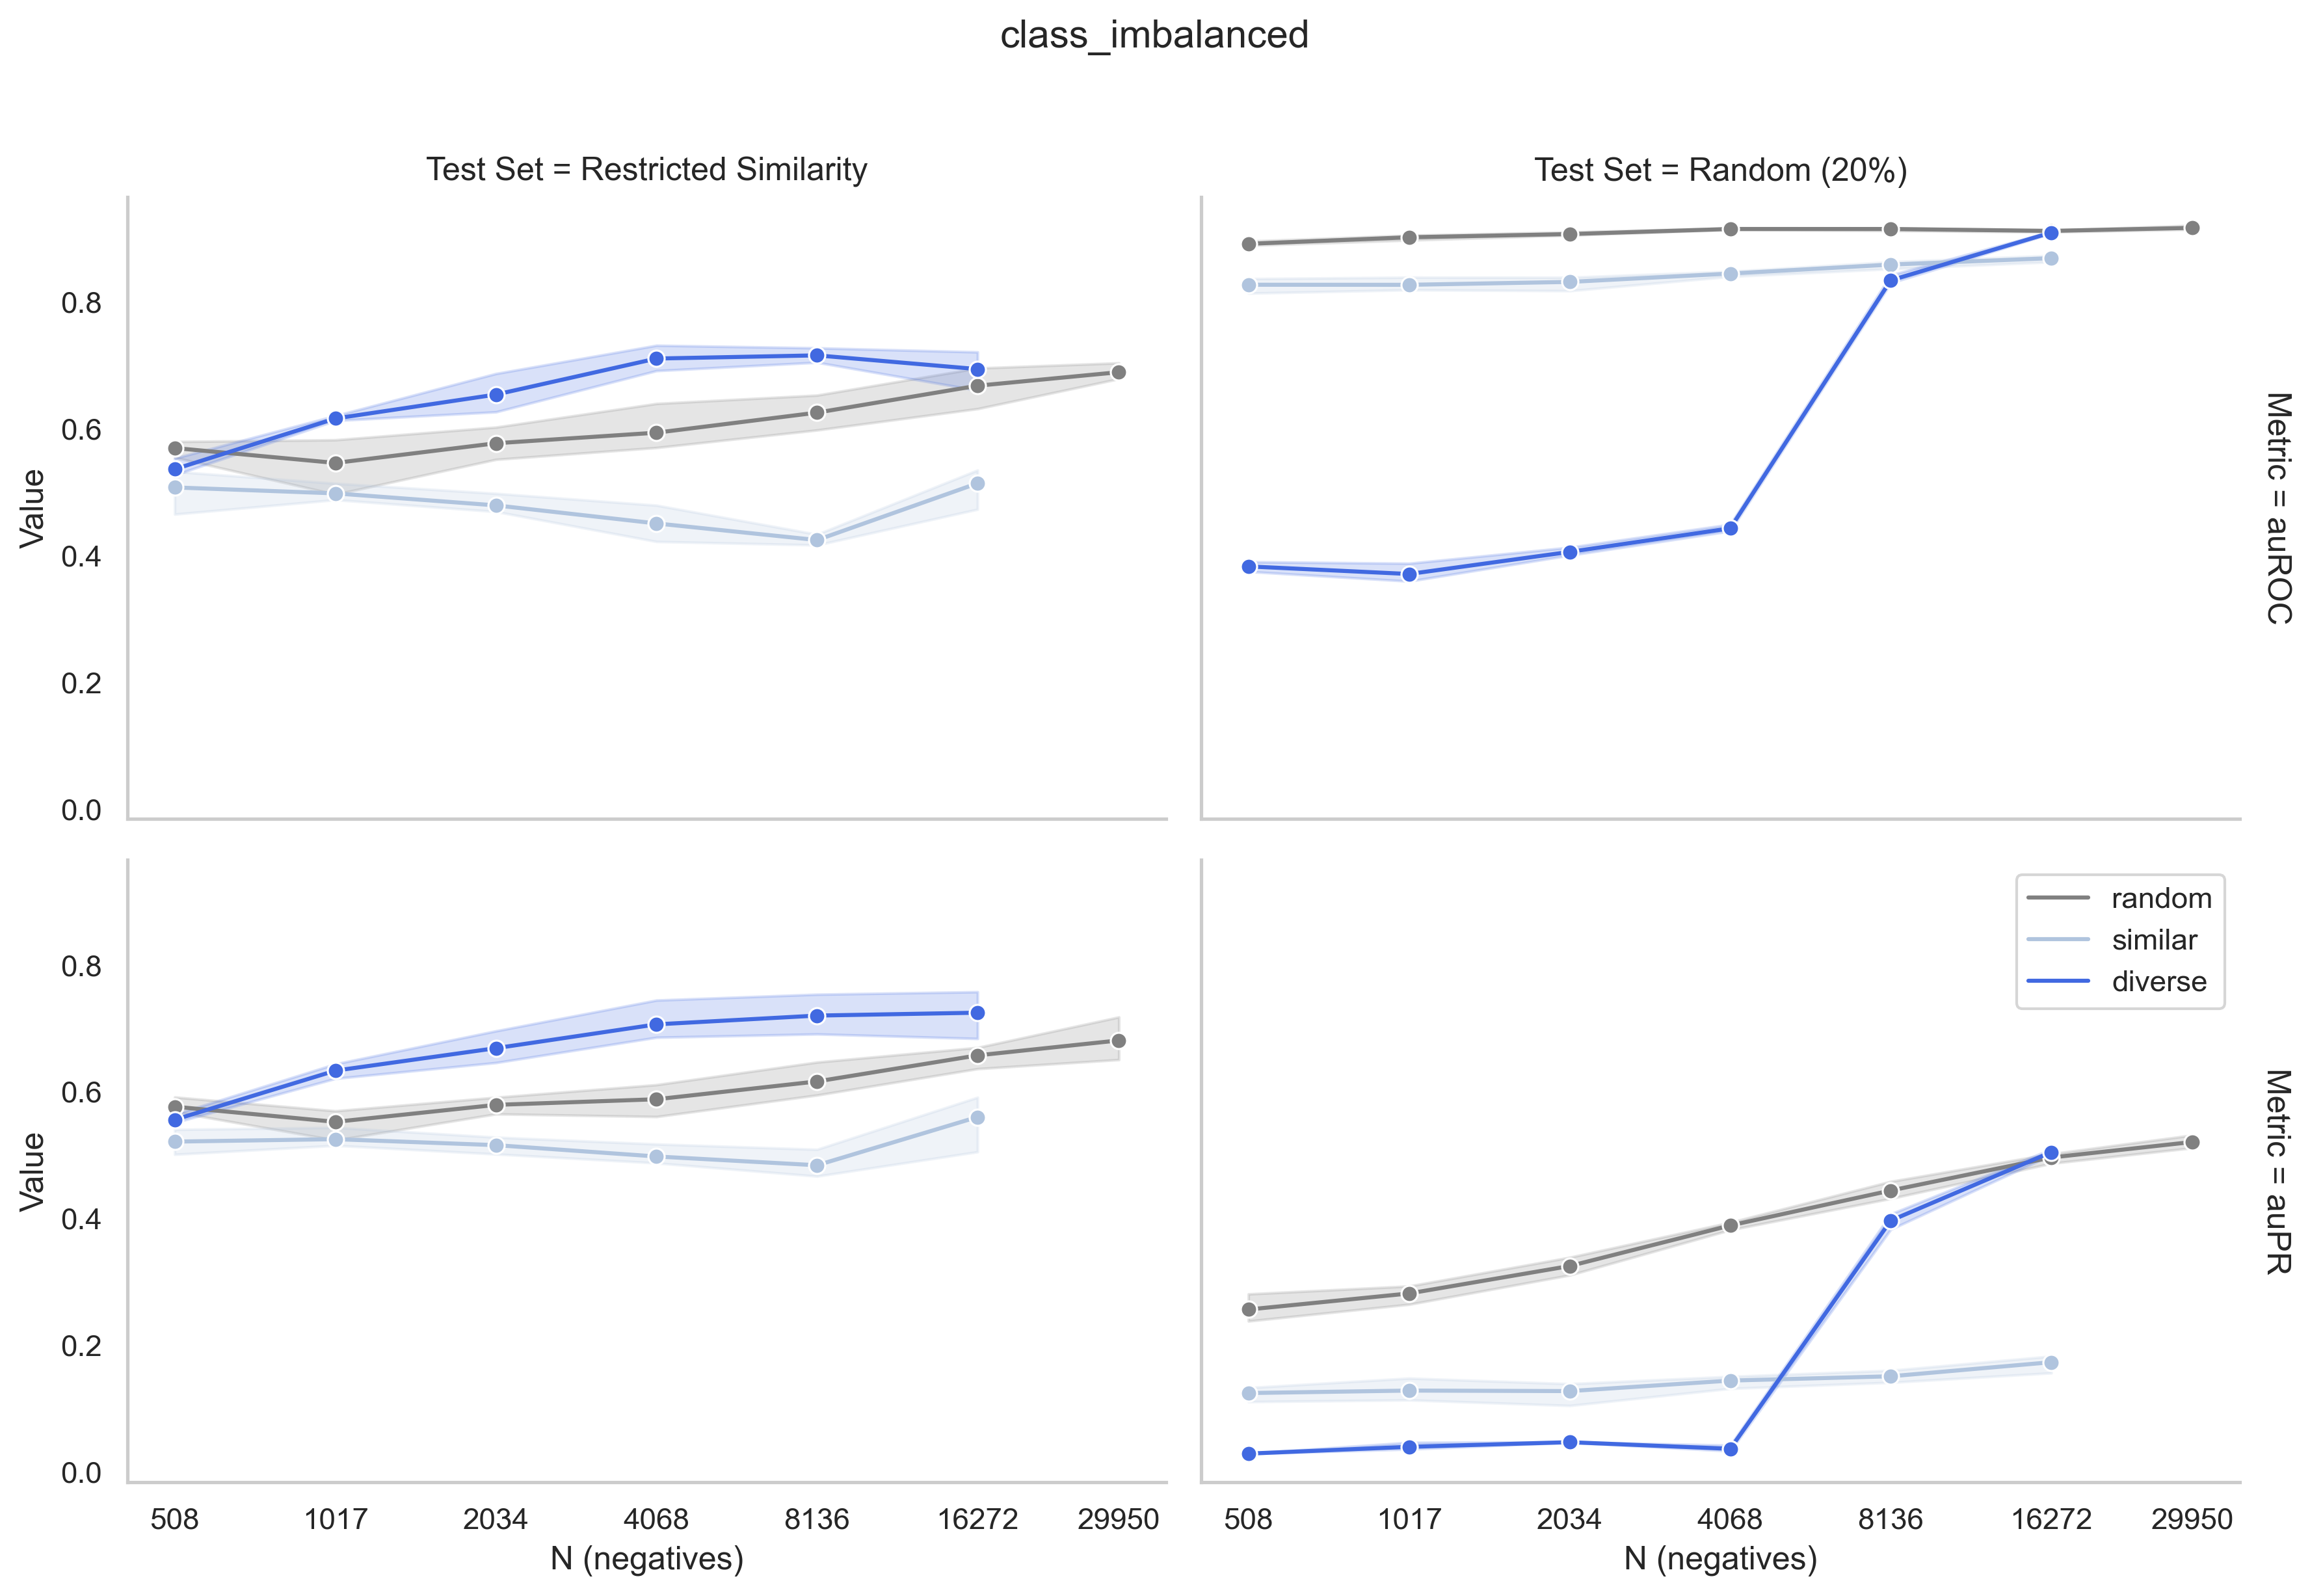


=== Plotting results for mode: class_balanced ===


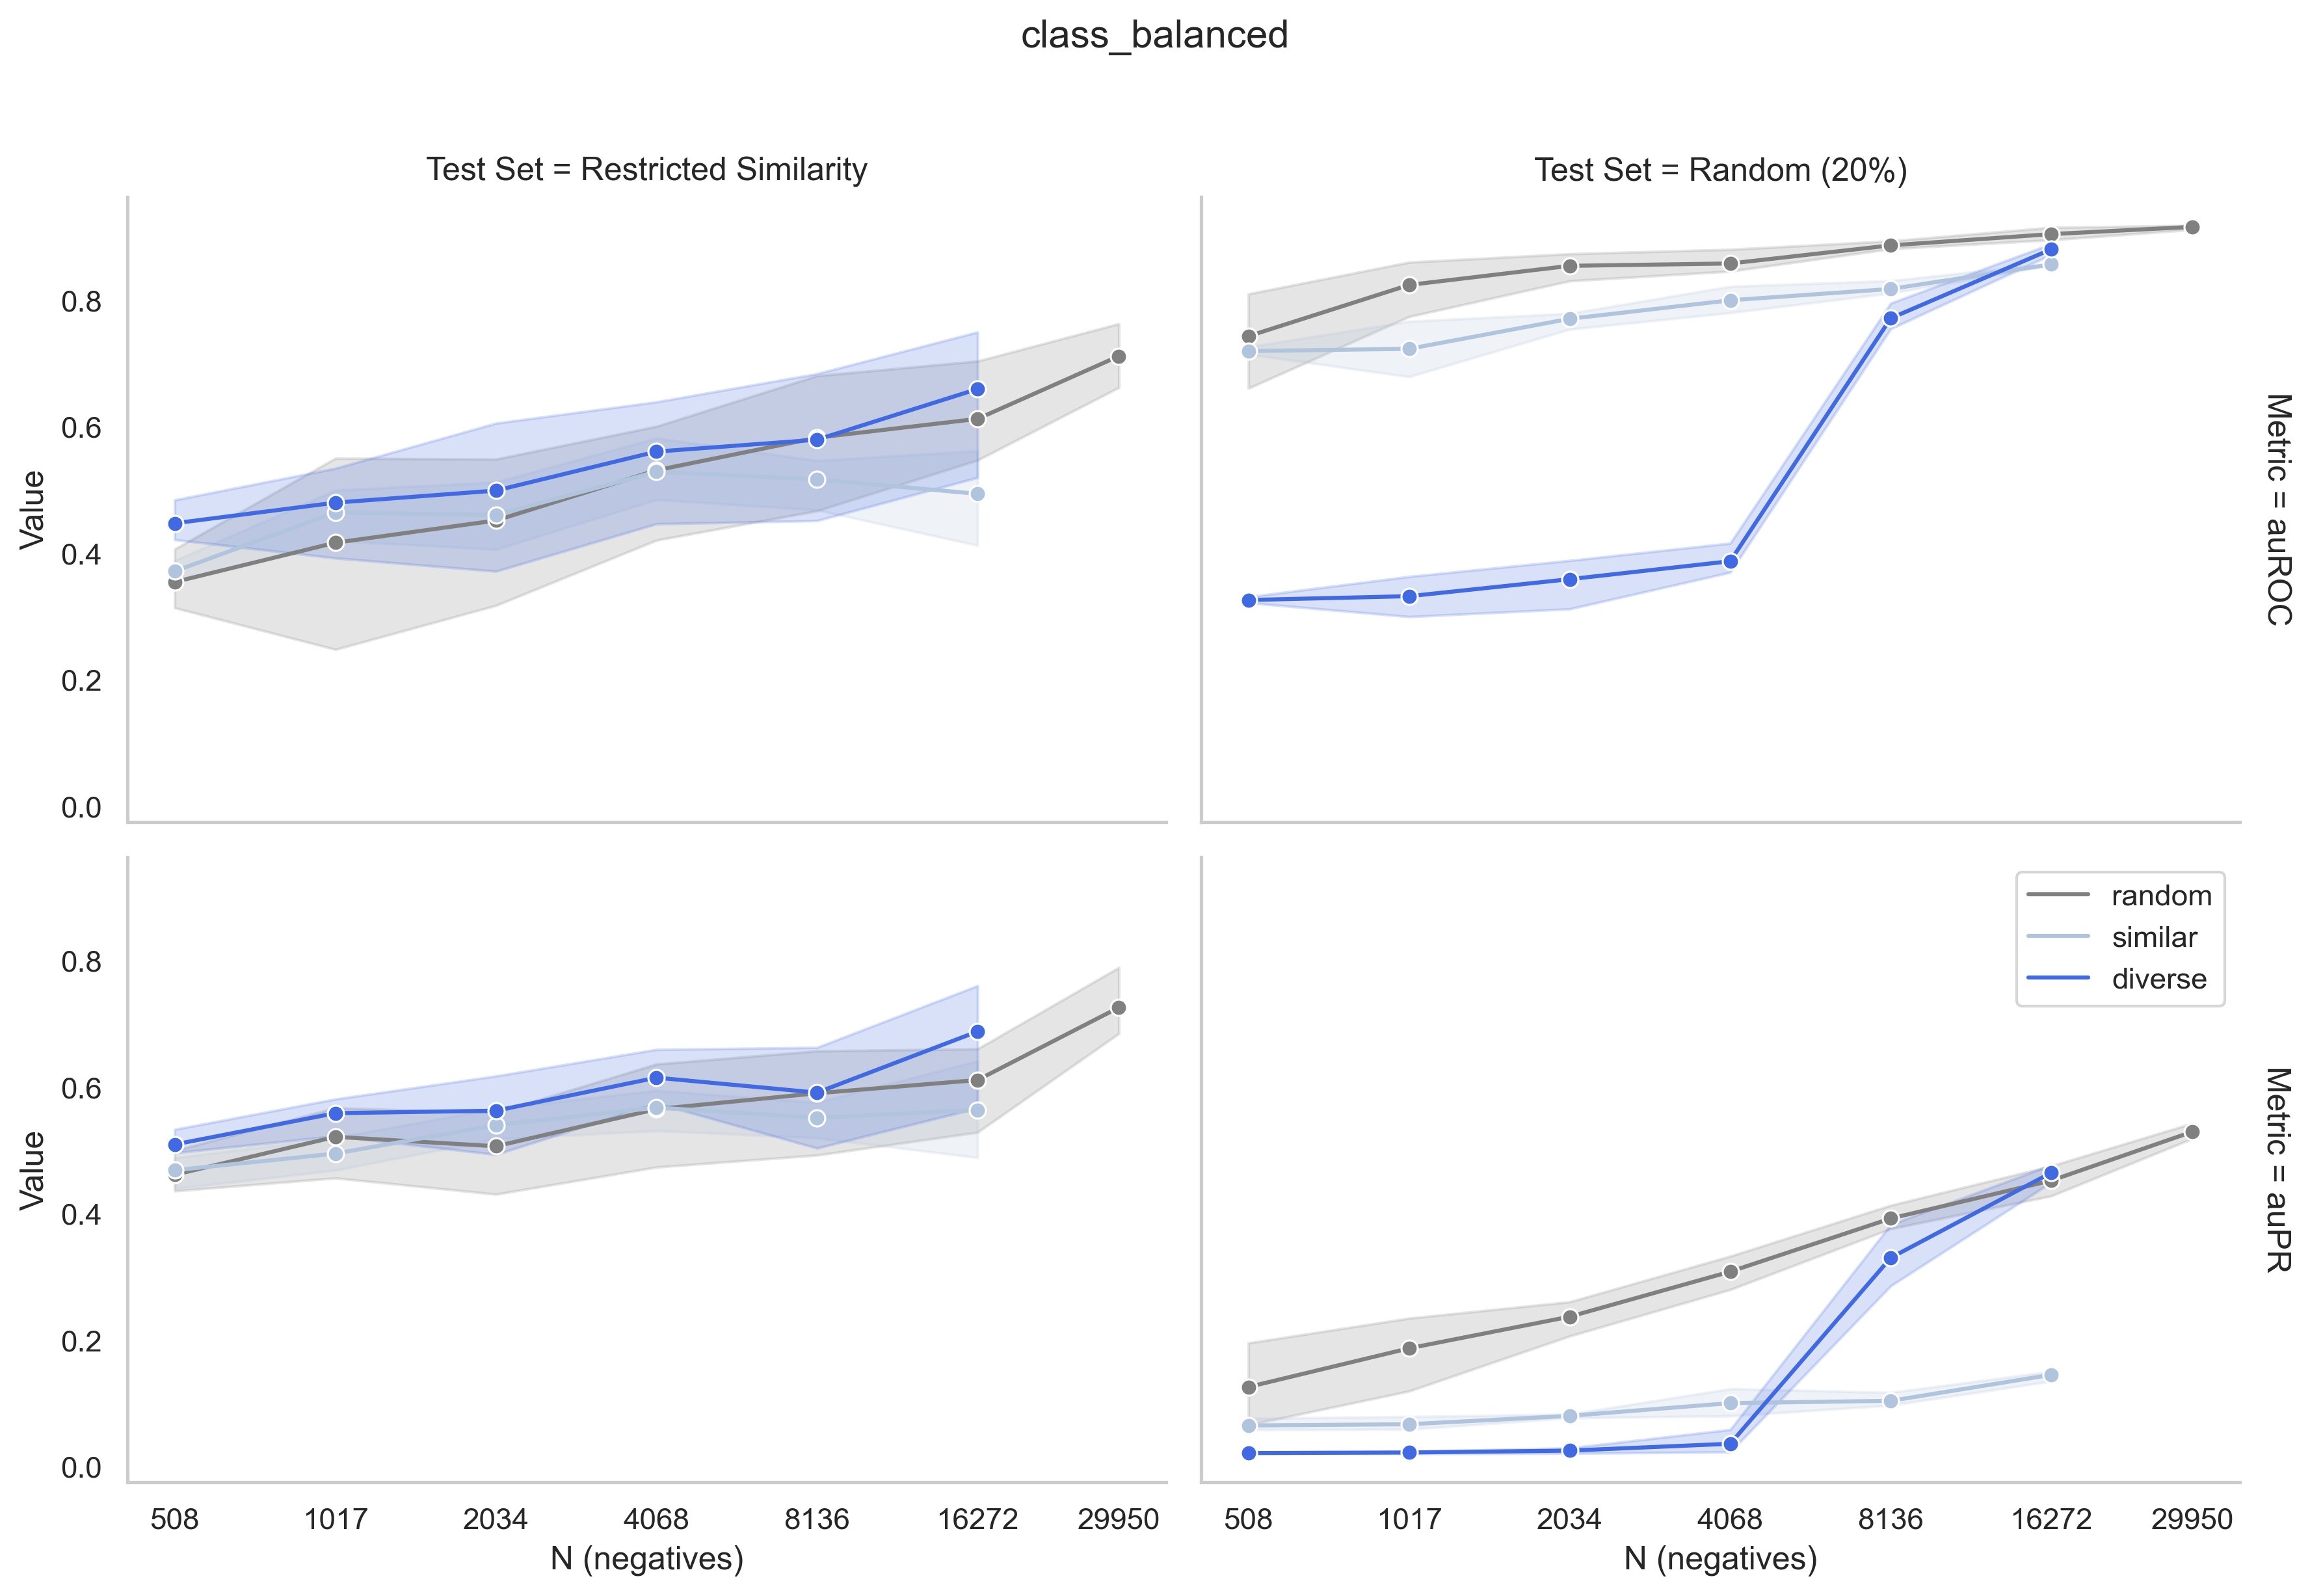

In [25]:
results = results.reset_index(drop=True)
order = ["random", "similar", "diverse"]
palette = dict(zip(order, ["grey", "lightsteelblue", "royalblue"]))
sns.set(rc={"figure.dpi": 300, "savefig.dpi": 300})
sns.set_style("whitegrid", {"axes.grid": False})

for mode_name, mode in modes.items():
    fig_dir = mode["fig_dir"]
    os.makedirs(fig_dir, exist_ok=True)
    mode_results = results[results["Mode"] == mode_name].reset_index(drop=True)
    if mode_results.empty:
        print(f"\n=== No results for mode: {mode_name}, skipping plot ===")
        continue
    print(f"\n=== Plotting results for mode: {mode_name} ===")

    g = sns.FacetGrid(
        mode_results,
        row="Metric",
        col="Test Set",
        sharey=True,
        height=4,
        aspect=1.5,
        margin_titles=True,
    )
    g.map(
        sns.lineplot,
        "N (negatives)",
        "Value",
        "Data Selection",
        marker="o",
        dashes=True,
        hue_order=order,
        palette=palette,
    )

    for ax in g.axes_dict.values():
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)
    g.set(xscale="log")
    # Only place ticks at sizes that actually appear in this mode's results to avoid
    # matplotlib warnings when a single-run mode has fewer rows.
    present_sizes = sorted(mode_results["N (negatives)"].unique())
    g.set(xticks=present_sizes)
    g.set(xticklabels=present_sizes)
    g.fig.suptitle(mode_name, y=1.02)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/fig.png")
    plt.savefig(f"{fig_dir}/fig.svg")
    plt.show()